## 1. Dataset Overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
df = pd.read_csv('faang_stock_prices.csv')
print(f"Dataset shape: {df.shape}")
df.head(6)

Dataset shape: (14964, 19)


,Date,Ticker,Open,High,Low,Close,Volume,SMA_7,SMA_21,EMA_12,EMA_26,RSI_14,MACD,MACD_Signal,Bollinger_Upper,Bollinger_Lower,Daily_Return,Volatility_7d,Next_Day_Close
0,2016-02-23,AAPL,21.853144,21.875812,21.433763,21.465500,127770400,21.782546,21.682435,21.720115,21.827292,52.112369,-0.107176,-0.149939,22.401531,20.889519,-0.022605,0.018130,21.785145
1,2016-02-23,AMZN,27.777500,27.845501,27.266500,27.646999,81016000,26.675857,27.140333,26.765295,27.363824,50.230010,-0.598529,-0.896261,31.103668,22.908382,-0.011725,0.022486,27.702000
2,2016-02-23,GOOGL,36.032746,36.270944,35.515157,35.595547,41332000,35.747473,36.132564,35.810892,36.019909,28.846871,-0.209017,-0.219158,38.439218,33.798573,-0.016131,0.015153,35.774696
3,2016-02-23,META,106.108789,106.724491,104.390794,104.728432,25319300,103.488525,103.976073,103.607174,102.390311,34.031434,1.216863,1.318966,115.829165,92.886882,-0.015864,0.019720,106.138588
4,2016-02-23,MSFT,46.158514,46.184970,44.959133,45.135513,28895300,45.542440,45.303900,45.301104,45.262960,42.877882,0.038144,-0.096534,48.143898,42.459504,-0.027920,0.019161,45.294239
5,2016-02-23,NVDA,0.762756,0.778123,0.759097,0.770805,369380000,0.710800,0.683503,0.704268,0.691066,67.878773,0.013203,-0.001797,0.780719,0.585314,0.002538,0.028025,0.776172


## 2. Variable Descriptions

In [3]:
print("Variable Types:")
print("- Date: Nominal (identifier)")
print("- Ticker: Nominal (categorical - 6 stocks)")
print("- Open, High, Low, Close: Ratio (price in $)")
print("- Volume: Ratio (number of shares traded)")
print("- SMA_7, SMA_21: Ratio (moving averages)")
print("- EMA_12, EMA_26: Ratio (exponential moving averages)")
print("- RSI_14: Interval (0-100 scale)")
print("- MACD, MACD_Signal: Interval (momentum indicators)")
print("- Bollinger_Upper, Bollinger_Lower: Ratio (price bands)")
print("- Daily_Return: Interval (percentage change)")
print("- Volatility_7d: Interval (7-day volatility)")
print("- Next_Day_Close: Ratio (target variable)")

Variable Types:
- Date: Nominal (identifier)
- Ticker: Nominal (categorical - 6 stocks)
- Open, High, Low, Close: Ratio (price in $)
- Volume: Ratio (number of shares traded)
- SMA_7, SMA_21: Ratio (moving averages)
- EMA_12, EMA_26: Ratio (exponential moving averages)
- RSI_14: Interval (0-100 scale)
- MACD, MACD_Signal: Interval (momentum indicators)
- Bollinger_Upper, Bollinger_Lower: Ratio (price bands)
- Daily_Return: Interval (percentage change)
- Volatility_7d: Interval (7-day volatility)
- Next_Day_Close: Ratio (target variable)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14964 entries, 0 to 14963
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             14964 non-null  str    
 1   Ticker           14964 non-null  str    
 2   Open             14964 non-null  float64
 3   High             14964 non-null  float64
 4   Low              14964 non-null  float64
 5   Close            14964 non-null  float64
 6   Volume           14964 non-null  int64  
 7   SMA_7            14964 non-null  float64
 8   SMA_21           14964 non-null  float64
 9   EMA_12           14964 non-null  float64
 10  EMA_26           14964 non-null  float64
 11  RSI_14           14964 non-null  float64
 12  MACD             14964 non-null  float64
 13  MACD_Signal      14964 non-null  float64
 14  Bollinger_Upper  14964 non-null  float64
 15  Bollinger_Lower  14964 non-null  float64
 16  Daily_Return     14964 non-null  float64
 17  Volatility_7d    14964 

## 3. Missing Values

In [5]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\nTotal missing: {missing.sum()}")

Missing values per column:
Date               0
Ticker             0
Open               0
High               0
Low                0
Close              0
Volume             0
SMA_7              0
SMA_21             0
EMA_12             0
EMA_26             0
RSI_14             0
MACD               0
MACD_Signal        0
Bollinger_Upper    0
Bollinger_Lower    0
Daily_Return       0
Volatility_7d      0
Next_Day_Close     0
dtype: int64

Total missing: 0


## 4. Outliers Analysis

In [6]:
numeric_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Return', 'RSI_14', 'Volatility_7d']

print("Outliers detection using IQR method:")
outliers_summary = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)][col]
    outliers_summary[col] = len(outliers)
    
print(outliers_summary)

Outliers detection using IQR method:
{'Open': 937, 'High': 931, 'Low': 941, 'Close': 937, 'Volume': 2243, 'Daily_Return': 949, 'RSI_14': 5, 'Volatility_7d': 750}


## 5. Feature Engineering

In [7]:
df['Price_Range'] = df['High'] - df['Low']
df['Price_Range_Pct'] = (df['High'] - df['Low']) / df['Close'] * 100
df['SMA_Crossover'] = df['SMA_7'] - df['SMA_21']
df['Bollinger_Width'] = df['Bollinger_Upper'] - df['Bollinger_Lower']
df['MACD_Histogram'] = df['MACD'] - df['MACD_Signal']

print("New features created:")
print("1. Price_Range: High - Low (absolute range)")
print("2. Price_Range_Pct: (High-Low)/Close * 100 (% range)")
print("3. SMA_Crossover: SMA_7 - SMA_21 (trend indicator)")
print("4. Bollinger_Width: Upper - Lower (volatility width)")
print("5. MACD_Histogram: MACD - Signal (momentum)")

New features created:
1. Price_Range: High - Low (absolute range)
2. Price_Range_Pct: (High-Low)/Close * 100 (% range)
3. SMA_Crossover: SMA_7 - SMA_21 (trend indicator)
4. Bollinger_Width: Upper - Lower (volatility width)
5. MACD_Histogram: MACD - Signal (momentum)


## 6. Univariate Analysis

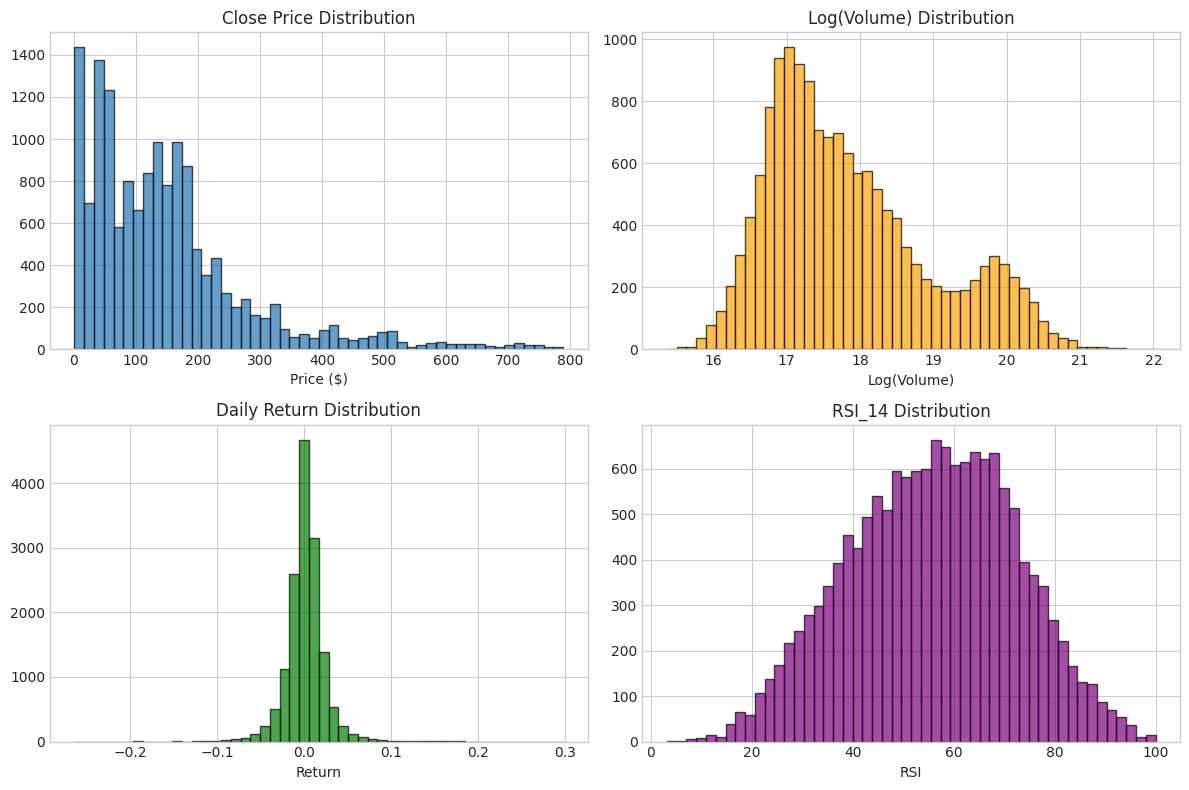

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

df['Close'].hist(bins=50, ax=axes[0, 0], edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Close Price Distribution')
axes[0, 0].set_xlabel('Price ($)')

np.log1p(df['Volume']).hist(bins=50, ax=axes[0, 1], edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_title('Log(Volume) Distribution')
axes[0, 1].set_xlabel('Log(Volume)')

df['Daily_Return'].hist(bins=50, ax=axes[1, 0], edgecolor='black', alpha=0.7, color='green')
axes[1, 0].set_title('Daily Return Distribution')
axes[1, 0].set_xlabel('Return')

df['RSI_14'].hist(bins=50, ax=axes[1, 1], edgecolor='black', alpha=0.7, color='purple')
axes[1, 1].set_title('RSI_14 Distribution')
axes[1, 1].set_xlabel('RSI')

plt.tight_layout()
plt.show()

In [9]:
df.describe()

,Open,High,Low,Close,Volume,SMA_7,SMA_21,EMA_12,EMA_26,RSI_14,...,Bollinger_Upper,Bollinger_Lower,Daily_Return,Volatility_7d,Next_Day_Close,Price_Range,Price_Range_Pct,SMA_Crossover,Bollinger_Width,MACD_Histogram
count,14964.000000,14964.000000,14964.000000,14964.000000,1.496400e+04,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000,...,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000,14964.000000
mean,147.969959,149.643762,146.256716,147.999839,1.186247e+08,147.631588,146.746646,147.314335,146.428158,55.686976,...,156.048174,137.572513,0.001335,0.018537,148.126287,3.387047,2.384791,0.884942,18.475662,-0.002063
std,132.599874,134.001750,131.065146,132.547711,1.889461e+08,132.261571,131.557653,131.956650,131.170115,16.597436,...,139.825874,123.751294,0.022069,0.012431,132.632577,3.827254,1.496467,6.514777,21.122935,1.245798
min,0.762756,0.777392,0.746413,0.767738,4.726100e+06,0.710800,0.683503,0.704268,0.691066,3.180003,...,0.780719,0.569458,-0.263901,0.001171,0.767738,0.009303,0.371458,-62.759283,0.048081,-11.424963
25%,50.094322,50.468777,49.669161,50.083026,2.428050e+07,49.906533,49.334041,49.600781,49.146090,43.754097,...,51.982837,47.077112,-0.008375,0.010449,50.149251,0.832282,1.396170,-0.795705,4.785143,-0.312441
50%,123.841343,125.102966,122.262753,123.922924,4.432600e+07,123.301276,122.667958,123.067546,122.222704,56.381405,...,131.496224,114.337861,0.001286,0.015466,124.013718,2.382004,2.003582,0.543440,12.949102,0.008720
75%,189.299623,191.429458,186.986899,189.079613,1.057329e+08,188.811102,187.325549,187.740894,186.739774,67.819077,...,199.721259,176.264492,0.011626,0.022748,189.254452,4.560375,2.918782,2.881374,24.646814,0.353632
max,789.972167,795.064526,779.657506,788.823792,3.692928e+09,775.982954,762.484980,766.193137,757.613109,100.000000,...,813.954233,734.580075,0.298067,0.120255,788.823792,85.586460,17.212572,55.760064,233.422929,13.118019


## 7. Bivariate Analysis

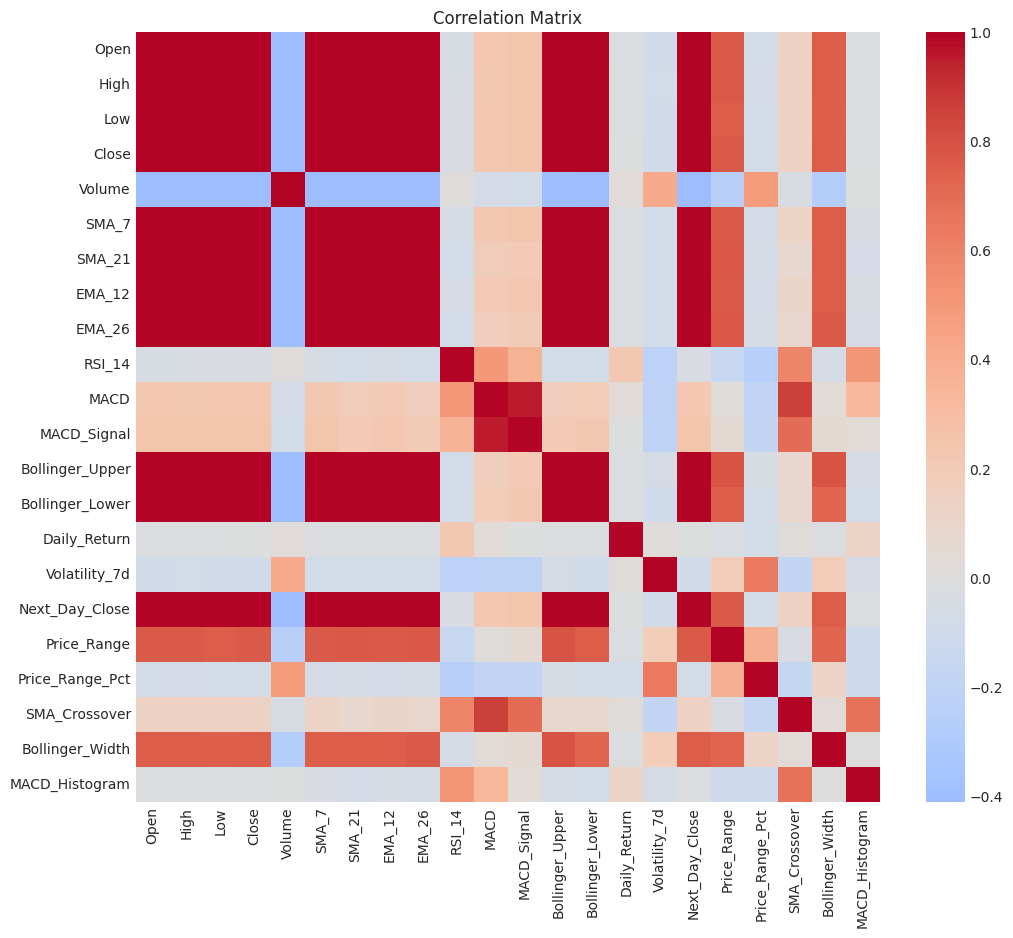

In [10]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [11]:
print("Top correlations with Next_Day_Close:")
print(corr_matrix['Next_Day_Close'].drop('Next_Day_Close').sort_values(ascending=False).head(10))

Top correlations with Next_Day_Close:
Close              0.999551
Low                0.999468
High               0.999452
Open               0.999335
SMA_7              0.998843
EMA_12             0.998600
EMA_26             0.997288
SMA_21             0.997073
Bollinger_Upper    0.995914
Bollinger_Lower    0.995771
Name: Next_Day_Close, dtype: float64


## 8. Model Building

In [12]:
feature_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'SMA_7', 'SMA_21', 
               'EMA_12', 'EMA_26', 'RSI_14', 'MACD', 'MACD_Signal',
               'Bollinger_Upper', 'Bollinger_Lower', 'Daily_Return', 'Volatility_7d']

target_col = 'Next_Day_Close'

df_sorted = df.sort_values('Date').reset_index(drop=True)
train_size = int(len(df_sorted) * 0.8)

X = df_sorted[feature_cols]
y = df_sorted[target_col]

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"Training size: {len(X_train)}, Test size: {len(X_test)}")

Training size: 11971, Test size: 2993


In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42)
}

results = []
for name, model in models.items():
    if 'Forest' in name or 'Boosting' in name:
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
    else:
        model.fit(X_train_scaled, y_train)
        pred = model.predict(X_test_scaled)
    
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    mae = mean_absolute_error(y_test, pred)
    r2 = r2_score(y_test, pred)
    mape = np.mean(np.abs((y_test - pred) / y_test)) * 100
    
    results.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'MAPE': mape})
    print(f"{name}: R²={r2:.4f}, RMSE={rmse:.2f}, MAE={mae:.2f}, MAPE={mape:.2f}%")

Linear Regression: R²=0.9985, RMSE=6.77, MAE=4.07, MAPE=1.47%
Ridge Regression: R²=0.9985, RMSE=6.77, MAE=4.09, MAPE=1.48%
Random Forest: R²=0.7005, RMSE=94.41, MAE=43.48, MAPE=8.14%
Gradient Boosting: R²=0.6873, RMSE=96.48, MAE=44.81, MAPE=8.37%
